In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta

# Step1: Data Colection

In [11]:
# Define date range: 10 years back from today
now = datetime.now()
start = datetime(now.year - 10, now.month, now.day)
end = now

# Download data with unadjusted Close + separate Adj Close column
ticker = 'AAPL'
df = yf.download(ticker, start, end, auto_adjust=False)

# Drop the 'Ticker' level from the MultiIndex columns
df.columns = df.columns.droplevel(1)

# Remove the leftover 'Price' name from the columns index
df.columns.name = None

# Move the Date index into a regular column
df = df.reset_index()

df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Adj Close,Close,High,Low,Open,Volume
0,2016-08-01,24.142246,26.512501,26.537500,26.102501,26.102501,152671600
1,2016-08-02,23.784834,26.120001,26.517500,26.000000,26.512501,135266400
2,2016-08-03,24.083055,26.447500,26.459999,26.192499,26.202499,120810400
3,2016-08-04,24.231833,26.467501,26.500000,26.320000,26.395000,109634800
4,2016-08-05,24.600328,26.870001,26.912500,26.545000,26.567499,162213600


# Step2: Data Exploration & Visualization

In [12]:
type(df)

pandas.core.frame.DataFrame

In [13]:
df.shape

(2513, 7)

In [14]:
df.isna().sum()

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [15]:
df.describe()

,Date,Adj Close,Close,High,Low,Open,Volume
count,2513,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,2021-07-28 08:29:24.902507008,128.887210,131.212657,132.528383,129.768926,131.082736,9.505846e+07
min,2016-08-01 00:00:00,23.604692,25.782499,26.430000,25.632500,25.662500,1.791060e+07
25%,2019-01-30 00:00:00,46.780777,48.922501,49.662498,48.447498,49.077499,5.598010e+07
50%,2021-07-28 00:00:00,133.080994,136.330002,137.649994,134.350006,136.279999,8.330540e+07
75%,2024-01-26 00:00:00,185.291397,187.149994,188.669998,185.190002,186.830002,1.151172e+08
max,2026-07-30 00:00:00,340.079987,340.079987,344.570007,337.350006,340.029999,4.479400e+08
std,NaN,79.245690,78.725976,79.502903,77.872973,78.632865,5.440104e+07


In [16]:
df.dtypes

Date         datetime64[ns]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object

In [17]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2016-08-01,24.142246,26.512501,26.537500,26.102501,26.102501,152671600
1,2016-08-02,23.784834,26.120001,26.517500,26.000000,26.512501,135266400
2,2016-08-03,24.083055,26.447500,26.459999,26.192499,26.202499,120810400
3,2016-08-04,24.231833,26.467501,26.500000,26.320000,26.395000,109634800
4,2016-08-05,24.600328,26.870001,26.912500,26.545000,26.567499,162213600


In [18]:
%matplotlib inline

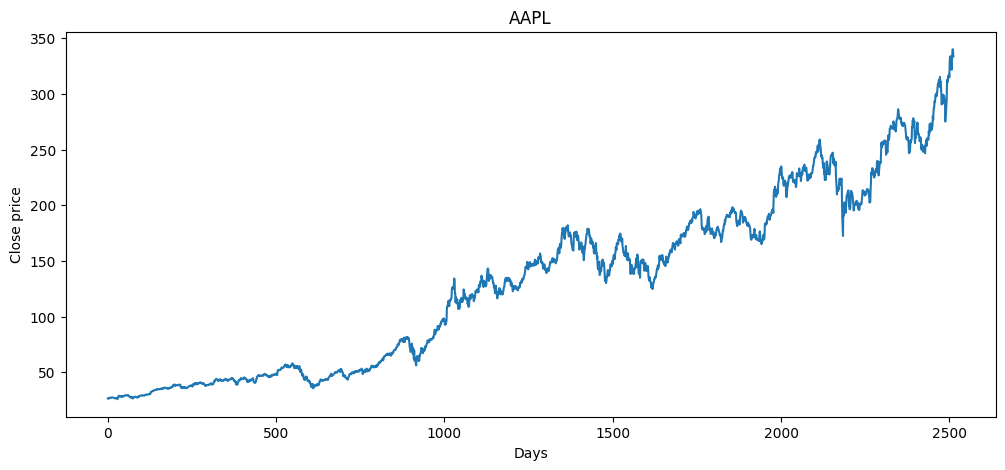

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price')
plt.show()

# Step3: Feature Engineering

In [23]:
temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_df[2:7])/5)

50.0


In [24]:
df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [25]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


# 100 days Moving Average

In [27]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,MA_100
0,2016-08-01,24.142246,26.512501,26.537500,26.102501,26.102501,152671600,NaN
1,2016-08-02,23.784834,26.120001,26.517500,26.000000,26.512501,135266400,NaN
2,2016-08-03,24.083055,26.447500,26.459999,26.192499,26.202499,120810400,NaN
3,2016-08-04,24.231833,26.467501,26.500000,26.320000,26.395000,109634800,NaN
4,2016-08-05,24.600328,26.870001,26.912500,26.545000,26.567499,162213600,NaN


In [28]:
df.head(103)

,Date,Adj Close,Close,High,Low,Open,Volume,MA_100
0,2016-08-01,24.142246,26.512501,26.537500,26.102501,26.102501,152671600,NaN
1,2016-08-02,23.784834,26.120001,26.517500,26.000000,26.512501,135266400,NaN
2,2016-08-03,24.083055,26.447500,26.459999,26.192499,26.202499,120810400,NaN
3,2016-08-04,24.231833,26.467501,26.500000,26.320000,26.395000,109634800,NaN
4,2016-08-05,24.600328,26.870001,26.912500,26.545000,26.567499,162213600,NaN
...,...,...,...,...,...,...,...,...
98,2016-12-19,26.833969,29.160000,29.344999,28.937500,28.950001,111117600,NaN
99,2016-12-20,26.905283,29.237499,29.375000,29.170000,29.184999,85700000,27.830000
100,2016-12-21,26.930588,29.264999,29.350000,29.195000,29.200001,95132800,27.857525
101,2016-12-22,26.753443,29.072500,29.127501,28.910000,29.087500,104343600,27.887050


Text(0, 0.5, 'Price')

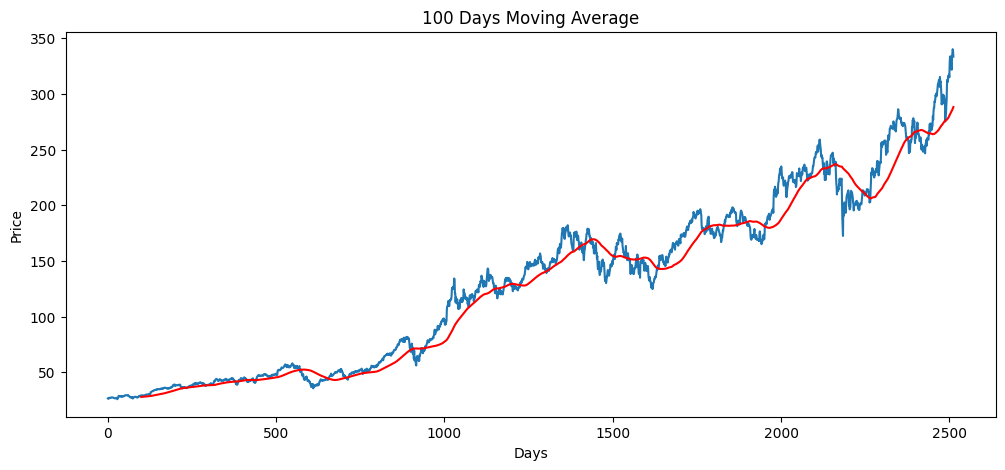

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

# 200 days Moving Average

In [31]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(203)

,Date,Adj Close,Close,High,Low,Open,Volume,MA_100,MA_200
0,2016-08-01,24.142246,26.512501,26.537500,26.102501,26.102501,152671600,NaN,NaN
1,2016-08-02,23.784834,26.120001,26.517500,26.000000,26.512501,135266400,NaN,NaN
2,2016-08-03,24.083055,26.447500,26.459999,26.192499,26.202499,120810400,NaN,NaN
3,2016-08-04,24.231833,26.467501,26.500000,26.320000,26.395000,109634800,NaN,NaN
4,2016-08-05,24.600328,26.870001,26.912500,26.545000,26.567499,162213600,NaN,NaN
...,...,...,...,...,...,...,...,...,...
198,2017-05-15,36.123829,38.924999,39.162498,38.762501,39.002499,104038800,33.692675,NaN
199,2017-05-16,36.070461,38.867500,39.014999,38.680000,38.985001,80194000,33.788975,30.809487
200,2017-05-17,34.859383,37.562500,38.642502,37.427502,38.400002,203070800,33.871950,30.864737
201,2017-05-18,35.390671,38.134998,38.334999,37.782501,37.817501,134272800,33.962575,30.924812


Text(0, 0.5, 'Price')

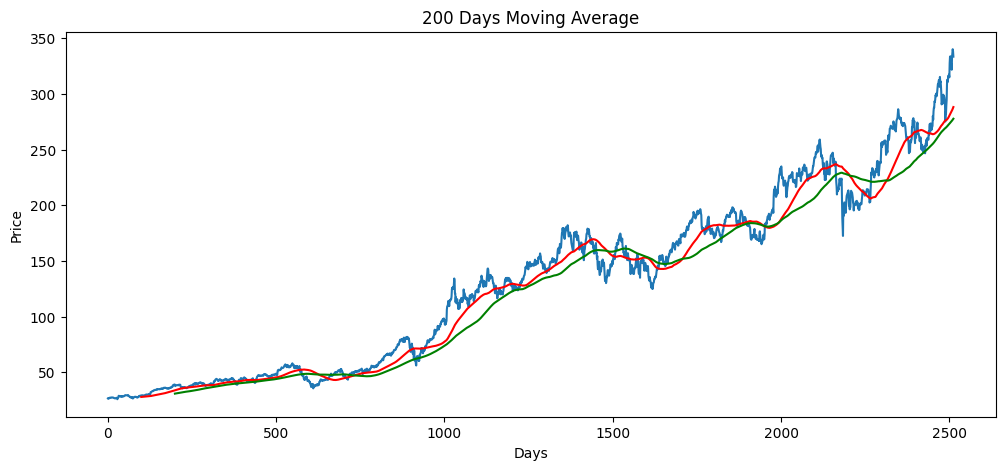

In [32]:

plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('200 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

In [34]:
df.tail()

,Date,Adj Close,Close,High,Low,Open,Volume,MA_100,MA_200
2508,2026-07-24,333.019989,333.019989,334.369995,321.619995,321.790009,47489400,285.1028,275.980449
2509,2026-07-27,336.910004,336.910004,339.570007,334.019989,334.540009,49604300,285.8344,276.382599
2510,2026-07-28,340.079987,340.079987,342.890015,335.600006,340.029999,51859000,286.6100,276.792699
2511,2026-07-29,338.190002,338.190002,344.570007,337.350006,339.730011,56090800,287.3890,277.213449
2512,2026-07-30,333.429993,333.429993,334.750000,329.589996,333.100006,73355100,288.1487,277.654249


# Calculating % change in each trading session

In [36]:
df['Percentage Chaged'] = df.Close.pct_change()
df[['Close', 'Percentage Chaged']]

,Close,Percentage Chaged
0,26.512501,NaN
1,26.120001,-0.014804
2,26.447500,0.012538
3,26.467501,0.000756
4,26.870001,0.015207
...,...,...
2508,333.019989,0.035317
2509,336.910004,0.011681
2510,340.079987,0.009409
2511,338.190002,-0.005557


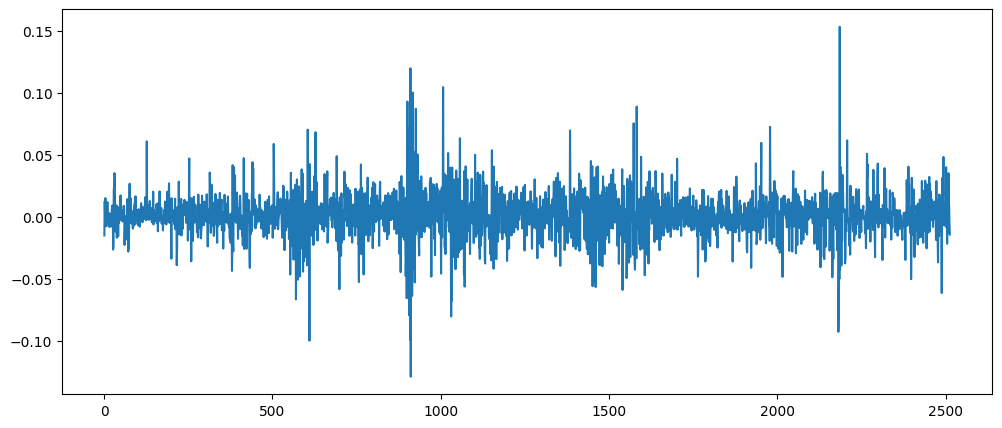

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage Chaged'])

# Step4: Data Preprocessing

In [42]:
df.shape

(2513, 10)

In [43]:
# Splitting data into Training & Testing datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7): int(len(df))])

print(data_training)
print(data_testing)

           Close
0      26.512501
1      26.120001
2      26.447500
3      26.467501
4      26.870001
...          ...
1754  191.940002
1755  192.750000
1756  193.619995
1757  194.500000
1758  193.220001

[1759 rows x 1 columns]
           Close
1759  195.830002
1760  196.449997
1761  195.610001
1762  192.580002
1763  191.169998
...          ...
2508  333.019989
2509  336.910004
2510  340.079987
2511  338.190002
2512  333.429993

[754 rows x 1 columns]


In [44]:
type(data_training)

pandas.core.frame.DataFrame

In [45]:
data_training

,Close
0,26.512501
1,26.120001
2,26.447500
3,26.467501
4,26.870001
...,...
1754,191.940002
1755,192.750000
1756,193.619995
1757,194.500000


In [46]:
data_testing

,Close
1759,195.830002
1760,196.449997
1761,195.610001
1762,192.580002
1763,191.169998
...,...
2508,333.019989
2509,336.910004
2510,340.079987
2511,338.190002


# Scaling down the data between 0 and 1

In [48]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [49]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00431144],
       [0.00199331],
       [0.00392754],
       ...,
       [0.99125896],
       [0.99645633],
       [0.98889657]])

In [50]:
type(data_training_array)

numpy.ndarray

In [52]:
np.ndarray

numpy.ndarray

In [53]:
data_training_array.shape

(1759, 1)

# Step5: Sequence Creation

In [55]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

In [56]:
x_train, y_train = np.array(x_train), np.array(y_train)

In [57]:
x_train

array([[[0.00431144],
        [0.00199331],
        [0.00392754],
        ...,
        [0.01895847],
        [0.01994773],
        [0.02040545]],

       [[0.00199331],
        [0.00392754],
        [0.00404566],
        ...,
        [0.01994773],
        [0.02040545],
        [0.02056787]],

       [[0.00392754],
        [0.00404566],
        [0.00642285],
        ...,
        [0.02040545],
        [0.02056787],
        [0.01943096]],

       ...,

       [[0.70593703],
        [0.70948071],
        [0.73971972],
        ...,
        [0.98836505],
        [0.98133682],
        [0.98612071]],

       [[0.70948071],
        [0.73971972],
        [0.75625672],
        ...,
        [0.98133682],
        [0.98612071],
        [0.99125896]],

       [[0.73971972],
        [0.75625672],
        [0.74308622],
        ...,
        [0.98612071],
        [0.99125896],
        [0.99645633]]])

In [58]:
y_train

array([0.02056787, 0.01943096, 0.01977055, ..., 0.99125896, 0.99645633,
       0.98889657])

In [59]:
x_train.shape

(1659, 100, 1)

In [60]:
y_train.shape

(1659,)

In [61]:
x_train.ndim

3

# Step6: Model Building

In [63]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [65]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [66]:
model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# Step7: Model Training

In [68]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - loss: 0.0337
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 7.5830e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - loss: 6.6476e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - loss: 6.8268e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 5.6013e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - loss: 5.4618e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - loss: 6.6763e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - loss: 5.2215e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - loss: 5.7716e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 5.5115e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - loss: 5.4131e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - loss: 5.2574e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - loss: 4.0474e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 4.1928e-04
Epoc

In [69]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [70]:
# Save the trained model
model.save('stock_prediction_model.keras')

# Step8: Preparing Test Data

In [72]:
data_training.tail(100)

,Close
1659,153.830002
1660,151.600006
1661,152.869995
1662,150.589996
1663,148.500000
...,...
1754,191.940002
1755,192.750000
1756,193.619995
1757,194.500000


In [73]:
data_testing

,Close
1759,195.830002
1760,196.449997
1761,195.610001
1762,192.580002
1763,191.169998
...,...
2508,333.019989
2509,336.910004
2510,340.079987
2511,338.190002


In [74]:
past_100_days = data_training.tail(100)

In [75]:
past_100_days

,Close
1659,153.830002
1660,151.600006
1661,152.869995
1662,150.589996
1663,148.500000
...,...
1754,191.940002
1755,192.750000
1756,193.619995
1757,194.500000


In [76]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

,Close
0,153.830002
1,151.600006
2,152.869995
3,150.589996
4,148.500000
...,...
849,333.019989
850,336.910004
851,340.079987
852,338.190002


In [77]:
input_data = scaler.fit_transform(final_df)
# input_data

In [78]:
input_data.shape

(854, 1)

In [79]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [80]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [81]:
x_test[0].shape

(100, 1)

In [82]:
x_test

array([[[0.02782129],
        [0.01618126],
        [0.02281029],
        ...,
        [0.23551518],
        [0.24010859],
        [0.23342731]],

       [[0.01618126],
        [0.02281029],
        [0.01090926],
        ...,
        [0.24010859],
        [0.23342731],
        [0.24705087]],

       [[0.02281029],
        [0.01090926],
        [0.        ],
        ...,
        [0.23342731],
        [0.24705087],
        [0.25028709]],

       ...,

       [[0.59515605],
        [0.58351611],
        [0.56874412],
        ...,
        [0.90385226],
        [0.96314856],
        [0.98345348]],

       [[0.58351611],
        [0.56874412],
        [0.58137599],
        ...,
        [0.96314856],
        [0.98345348],
        [1.        ]],

       [[0.56874412],
        [0.58137599],
        [0.58633466],
        ...,
        [0.98345348],
        [1.        ],
        [0.99013475]]])

# Step9: Making Prediction

In [84]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


In [85]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

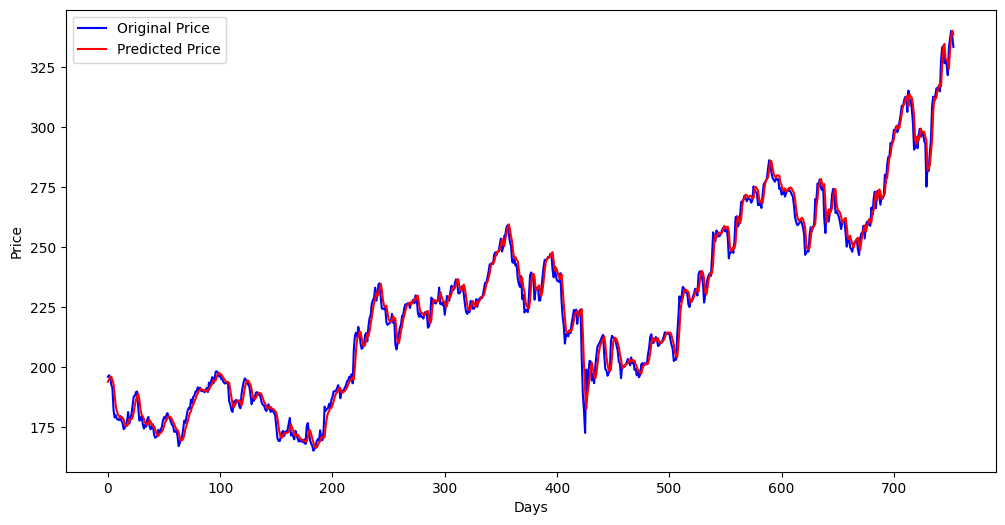

In [86]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

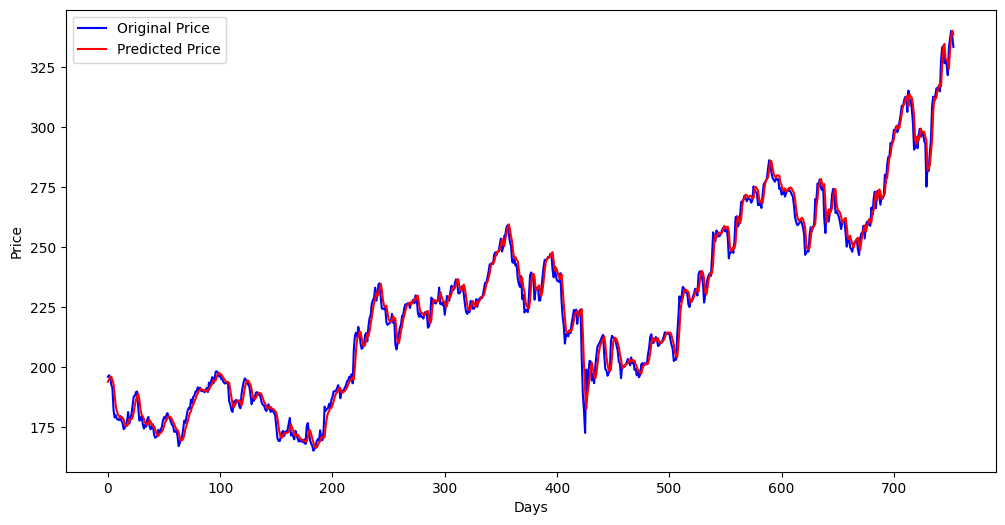

In [88]:

plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

# Step10: Model Evaluation

In [90]:
# Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error, r2_score

In [91]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 18.5018675359919


In [92]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 4.301379724692055


In [93]:
# R-Squared
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.9880330766780769
